In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('C:\Movies and series\important\Projects\Healthcare\diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv')
df.head()

<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
C:\Users\rouna\AppData\Local\Temp\ipykernel_42372\1913047580.py:3: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('C:\Movies and series\important\Projects\Healthcare\diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv')


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
df.shape

(101766, 50)

In [3]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [5]:
df["readmit_30d"] = (df["readmitted"] == "<30").astype(int)
df["readmit_30d"].head()

0    0
1    0
2    0
3    0
4    0
Name: readmit_30d, dtype: int32

In [6]:
df["readmit_30d"].mean()
df["readmit_30d"].mean() * 100

11.159915885462727

In [7]:
df.groupby("age")["readmit_30d"].mean().reset_index()

,age,readmit_30d
0,[0-10),0.018634
1,[10-20),0.057887
2,[20-30),0.142426
3,[30-40),0.112318
4,[40-50),0.106040
5,[50-60),0.096662
6,[60-70),0.111284
7,[70-80),0.117731
8,[80-90),0.120835
9,[90-100),0.110992


In [8]:
age_readmit = df.groupby("age")["readmit_30d"].mean().reset_index()
age_readmit["readmit_pct"] = age_readmit["readmit_30d"] * 100
age_readmit

,age,readmit_30d,readmit_pct
0,[0-10),0.018634,1.863354
1,[10-20),0.057887,5.788712
2,[20-30),0.142426,14.242607
3,[30-40),0.112318,11.231788
4,[40-50),0.106040,10.604027
5,[50-60),0.096662,9.666203
6,[60-70),0.111284,11.128408
7,[70-80),0.117731,11.773055
8,[80-90),0.120835,12.083503
9,[90-100),0.110992,11.099177


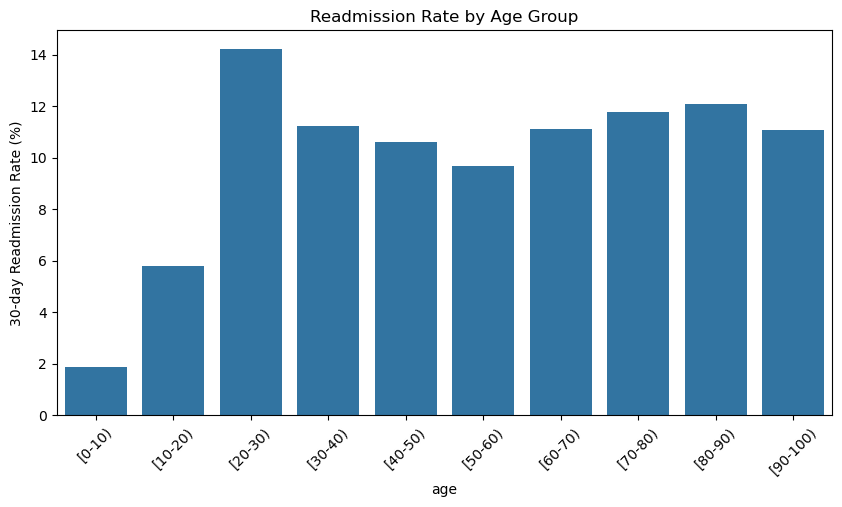

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(data=age_readmit, x="age", y="readmit_pct")
plt.xticks(rotation=45)
plt.ylabel("30-day Readmission Rate (%)")
plt.title("Readmission Rate by Age Group")
plt.show()

In [10]:
stay_readmit = df.groupby("readmit_30d")["time_in_hospital"].mean()
stay_readmit

readmit_30d
0    4.349224
1    4.768249
Name: time_in_hospital, dtype: float64

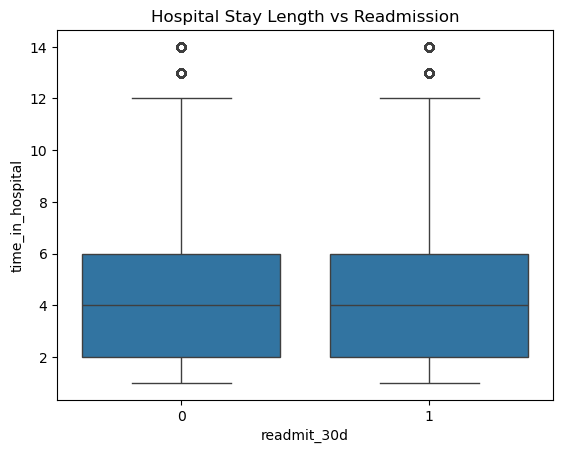

In [11]:
sns.boxplot(data=df, x="readmit_30d", y="time_in_hospital")
plt.title("Hospital Stay Length vs Readmission")
plt.show()

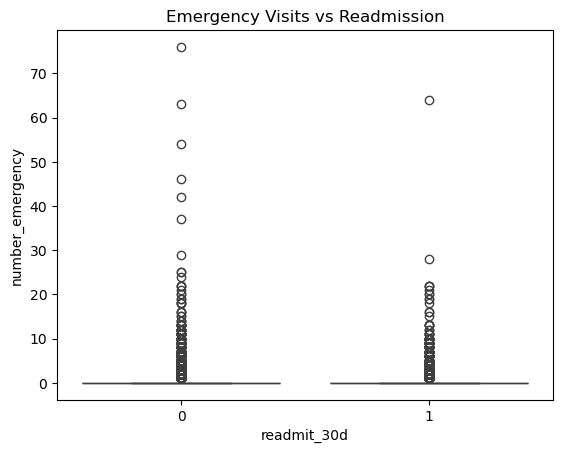

In [12]:
df.groupby("readmit_30d")["number_emergency"].mean()
sns.boxplot(data=df, x="readmit_30d", y="number_emergency")
plt.title("Emergency Visits vs Readmission")
plt.show()

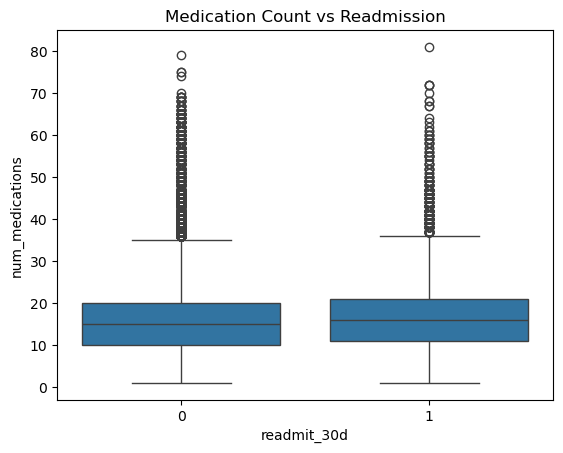

In [13]:
df.groupby("readmit_30d")["num_medications"].mean()
sns.boxplot(data=df, x="readmit_30d", y="num_medications")
plt.title("Medication Count vs Readmission")
plt.show()

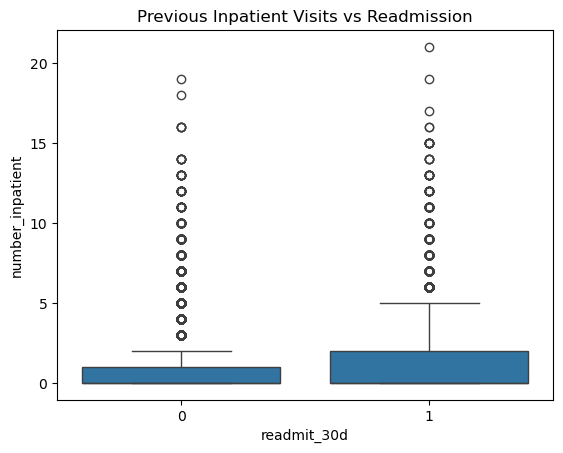

In [14]:
df.groupby("readmit_30d")["number_inpatient"].mean()
sns.boxplot(data=df, x="readmit_30d", y="number_inpatient")
plt.title("Previous Inpatient Visits vs Readmission")
plt.show()

In [15]:
df.groupby("readmit_30d")["number_inpatient"].mean()

readmit_30d
0    0.561648
1    1.224003
Name: number_inpatient, dtype: float64

In [16]:
features = [
    "time_in_hospital",
    "num_medications",
    "number_emergency",
    "number_inpatient",
    "number_outpatient",
    "number_diagnoses"
]

X = df[features]
y = df["readmit_30d"]

In [17]:
features = [
    "time_in_hospital",
    "num_medications",
    "number_emergency",
    "number_inpatient",
    "number_outpatient",
    "number_diagnoses"
]

X = df[features]
y = df["readmit_30d"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8873440110052078
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.44      0.01      0.02      2285

    accuracy                           0.89     20354
   macro avg       0.66      0.51      0.48     20354
weighted avg       0.84      0.89      0.84     20354



In [23]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

0.6285330739822657

In [24]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
3,number_inpatient,0.268261
5,number_diagnoses,0.052501
2,number_emergency,0.038057
0,time_in_hospital,0.024407
1,num_medications,0.004456
4,number_outpatient,-0.003284


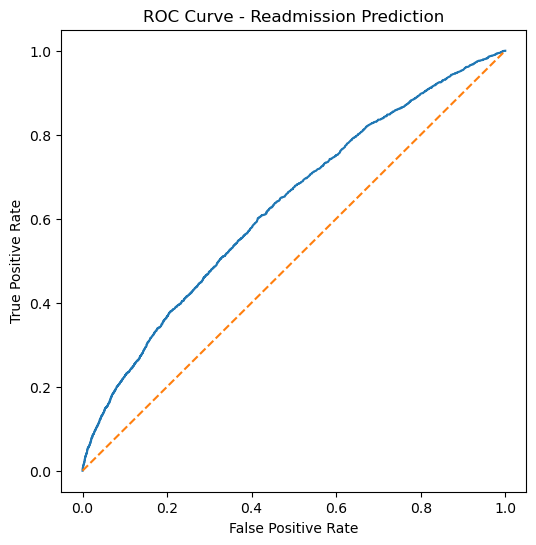

In [25]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Readmission Prediction")
plt.show()